# Exploratory Data Analysis

This notebook is the comprehensive EDA reference. It uses the **eda_starter_template** module to load data, run analyses, and generate visualizations. All exploratory work and supporting results are included here; the executive summary lives in `EDA_Executive.ipynb`.

## Fear and Greed Index Exploration

The **Crypto Fear and Greed Index (FGI)**, developed by Alternative.me, is a composite sentiment metric that measures the prevailing psychological state of the market on a scale from 0 to 100. Rather than looking strictly at price, the index calculates a "magic number" by aggregating six distinct quantitative and qualitative indicators:
* **Volatility (25%):** Current price swings compared to 30- and 90-day averages.
* **Market Momentum & Volume (25%):** Current buying/selling volume against 30- and 90-day trends.
* **Social Media (15%):** Interaction rates, hashtags, and public interest on platforms like Twitter.
* **Surveys (15%):** Weekly polling of individual investor outlooks.
* **Bitcoin Dominance (10%):** BTC's market cap share relative to speculative altcoins.
* **Search Trends (10%):** Google search volumes for specific Bitcoin-related queries.

### Why is it relevant?
In a Bitcoin accumulation model, market psychology is just as critical as raw price action. By quantifying human emotion, the FGI acts as a powerful **contrarian indicator**:
* **Extreme Fear (0-24):** Indicates investors are overly bearish. This often correlates with market capitulation, potential undervaluation, and an optimal time to increase accumulation (buy the dip).
* **Extreme Greed (76-100):** Indicates investors are overly bullish. This signals market froth, overvaluation, and an optimal time to decrease accumulation or begin distribution (taking profits).

### What are we trying to do?
In this section, we will load the historical FGI dataset from our local `data/` folder, merge it with our Bitcoin price history, and rigorously backtest its relationship against future price momentum. Our goal is to determine if these sentiment extremes can serve as reliable algorithmic triggers to optimize when we buy and when we sell.

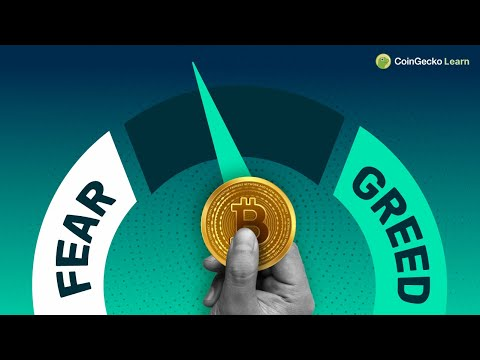

In [1]:
## Here is just a short introduction of what FGI is.

from IPython.display import YouTubeVideo
YouTubeVideo("xwv0abKb2h8", width=600, height=300)

In [2]:
#pip install -r requirements.txt

In [3]:
# Setup: use eda_starter_template from this repo
import sys
from pathlib import Path

# Dynamically resolve the current working directory
cwd = Path.cwd()

# If the notebook is running from the project root
if (cwd / "eda" / "eda_starter_template.py").exists():
    sys.path.insert(0, str(cwd))
    from eda.eda_starter_template import (
        load_bitcoin_data,
        load_polymarket_data,
        COINMETRICS_PATH,
        POLYMARKET_DIR,
        analyze_btc_metrics,
        analyze_polymarket_summary,
        plot_btc_price,
        plot_polymarket_volume,
        track_memory,
        get_memory_usage_mb,
        format_memory,
        PLOTS_DIR,
    )
# If the notebook is running from inside the 'eda' directory
elif (cwd / "eda_starter_template.py").exists():
    # Insert the parent directory into sys.path just in case other modules need it
    sys.path.insert(0, str(cwd.parent)) 
    from eda_starter_template import (
        load_bitcoin_data,
        load_polymarket_data,
        COINMETRICS_PATH,
        POLYMARKET_DIR,
        analyze_btc_metrics,
        analyze_polymarket_summary,
        plot_btc_price,
        plot_polymarket_volume,
        track_memory,
        get_memory_usage_mb,
        format_memory,
        PLOTS_DIR,
    )
else:
    raise ImportError(f"Could not find eda_starter_template.py from {cwd}. Run notebook from project root or eda/.")

print("Initial memory:", format_memory(get_memory_usage_mb()))

Initial memory: 221.46 MB


In [4]:
btc_df = load_bitcoin_data(COINMETRICS_PATH)
if btc_df is not None:
    display(btc_df.head())
    print("Shape:", btc_df.shape)

Loading Bitcoin data from C:\Users\eschi\Documents\CSE 7648\bitcoin-analytics-capstone-template-agopalkr\data\Coin Metrics\coinmetrics_btc.csv...
[Memory] Before loading Bitcoin data: 221.49 MB
[Memory] After loading Bitcoin data: 246.79 MB (Δ 25.30 MB)
Successfully loaded 6221 rows.


time,AdrActCnt,AdrBalCnt,AssetCompletionTime,AssetEODCompletionTime,BlkCnt,CapMVRVCur,CapMrktCurUSD,CapMrktEstUSD,FeeTotNtv,FlowInExNtv,FlowInExUSD,FlowOutExNtv,FlowOutExUSD,HashRate,IssTotNtv,IssTotUSD,PriceBTC,PriceUSD,ROI1yr,ROI30d,ReferenceRate,ReferenceRateETH,ReferenceRateEUR,ReferenceRateUSD,SplyCur,SplyExNtv,SplyExUSD,SplyExpFut10yr,TxCnt,TxTfrCnt,volume_reported_spot_usd_1d
datetime[μs],i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64
2009-01-03 00:00:00,0,0,1614334883,1614334883,0,null,null,null,0.0,0.0,null,0.0,null,null,null,null,1,null,null,null,null,null,null,null,0.0,0.0,null,null,0,0,null
2009-01-04 00:00:00,0,0,1614334883,1614334883,0,null,null,null,0.0,0.0,null,0.0,null,null,null,null,1,null,null,null,null,null,null,null,0.0,0.0,null,null,0,0,null
2009-01-05 00:00:00,0,0,1614334883,1614334883,0,null,null,null,0.0,0.0,null,0.0,null,null,null,null,1,null,null,null,null,null,null,null,0.0,0.0,null,null,0,0,null
2009-01-06 00:00:00,0,0,1614334884,1614334884,0,null,null,null,0.0,0.0,null,0.0,null,null,null,null,1,null,null,null,null,null,null,null,0.0,0.0,null,null,0,0,null
2009-01-07 00:00:00,0,0,1614334885,1614334885,0,null,null,null,0.0,0.0,null,0.0,null,null,null,null,1,null,null,null,null,null,null,null,0.0,0.0,null,null,0,0,null


Shape: (6221, 32)


In [5]:
# ## Here I used Alternative.me to extract FGI
# # The Alternative.me API does NOT require an API key!

# import requests
# import pandas as pd
# import os

# url = 'https://api.alternative.me/fng/?limit=0'

# print("Fetching historical Fear and Greed Index data from Alternative.me...")
# response = requests.get(url)

# if response.status_code == 200:
#     data = response.json()['data']
    
#     # Parse into pandas DataFrame
#     fgi_df = pd.DataFrame(data)
    
#     # Convert Unix timestamp to a standard date
#     fgi_df['timestamp'] = pd.to_datetime(fgi_df['timestamp'].astype(float), unit='s')
#     fgi_df['date'] = fgi_df['timestamp'].dt.date
#     fgi_df['value'] = fgi_df['value'].astype(float)
    
#     # Keep only the relevant columns and sort chronologically (oldest to newest)
#     fgi_df = fgi_df[['date', 'value', 'value_classification']].sort_values('date').reset_index(drop=True)
    
#     # Filter for the requested timeframe (Feb 2018 through the end of 2024)
#     # Note: 2016-2017 FGI data does not exist
#     fgi_df['date_pd'] = pd.to_datetime(fgi_df['date'])
#     fgi_df = fgi_df[(fgi_df['date_pd'].dt.year >= 2018) & (fgi_df['date_pd'].dt.year <= 2024)]
    
#     # Drop the temporary datetime column
#     fgi_df = fgi_df.drop(columns=['date_pd']).reset_index(drop=True)
    
#     # Define the target directory using a raw string to handle Windows backslashes
#     target_dir = r"C:\Users\eschi\Documents\CSE 7648\bitcoin-analytics-capstone-template-agopalkr\data"
    
#     # Ensure the directory actually exists; if not, create it safely
#     os.makedirs(target_dir, exist_ok=True)
    
#     # Create the full file path
#     fgi_csv_path = os.path.join(target_dir, 'crypto_fear_and_greed_index_2018_2024.csv')
    
#     # Save the table for future use in backtesting/modeling
#     fgi_df.to_csv(fgi_csv_path, index=False)
    
#     print(f"\n Successfully loaded {len(fgi_df)} records (Feb 2018 to Dec 2024).")
#     print(f" Data saved to: {fgi_csv_path}")
#     display(fgi_df.head())
#     display(fgi_df.tail())
# else:
#     print(f" Failed to fetch data. Status Code: {response.status_code}")

In [6]:
import pandas as pd
from pathlib import Path

# Dynamically route the path based on the notebook's current working directory
current_dir = Path.cwd()

# Check if 'data' is in the current directory (if notebook is in repo root)
# Or if it's one level up (if notebook is inside a 'notebooks' subfolder)
if (current_dir / "data").exists():
    data_dir = current_dir / "data"
else:
    data_dir = current_dir.parent / "data"

# Construct the OS-agnostic path to the CSV file
file_path = data_dir / "crypto_fear_and_greed_index_2018_2024.csv"

print(f"Attempting to load FGI data from: {file_path}")

if file_path.exists():
    # Load the CSV into a pandas DataFrame
    fgi_df = pd.read_csv(file_path)
    
    # Ensure the 'date' column is correctly parsed as a date object for merging later
    fgi_df['date'] = pd.to_datetime(fgi_df['date']).dt.date
    
    print(f" Successfully loaded {len(fgi_df)} records.")
    display(fgi_df.head())
else:
    print(f" File not found at: {file_path}")
    print("Please ensure the data file exists in the repository's 'data' folder.")

Attempting to load FGI data from: C:\Users\eschi\Documents\CSE 7648\bitcoin-analytics-capstone-template-agopalkr\data\crypto_fear_and_greed_index_2018_2024.csv
 Successfully loaded 2522 records.


,date,value,value_classification
0,2018-02-01,30.0,Fear
1,2018-02-02,15.0,Extreme Fear
2,2018-02-03,40.0,Fear
3,2018-02-04,24.0,Extreme Fear
4,2018-02-05,11.0,Extreme Fear


Merging Fear and Greed Index with Bitcoin price data...

Pearson Correlation between FGI and Bitcoin PriceUSD: 0.4237


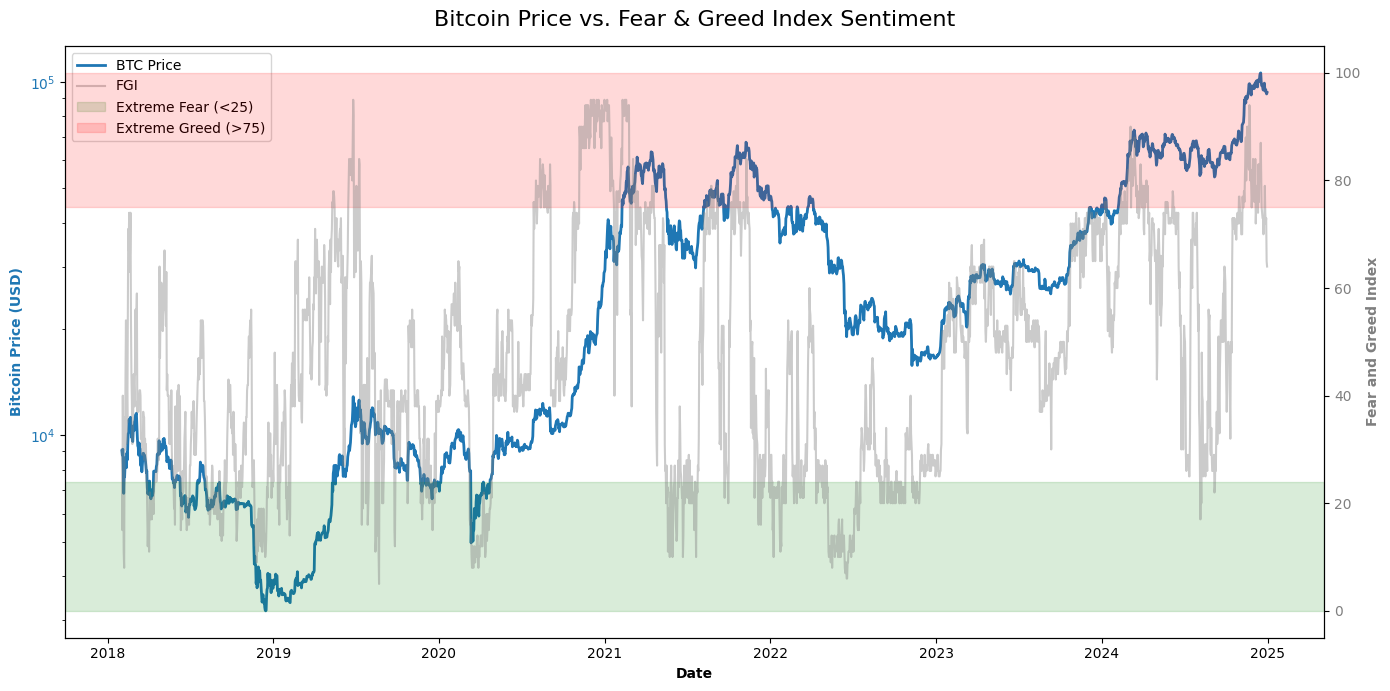

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl
import numpy as np

# Ensure `btc_df` from earlier in the notebook and `fgi_df` exist
if 'btc_df' in locals() and btc_df is not None and 'fgi_df' in locals():
    print("Merging Fear and Greed Index with Bitcoin price data...")
    
    # 1. Convert pandas fgi_df to polars for joining
    fgi_pl = pl.from_pandas(fgi_df)
    
    # 2. Extract date from btc_df for merging
    if "date" not in btc_df.columns:
        btc_date_df = btc_df.with_columns(pl.col("time").dt.date().alias("date"))
    else:
        btc_date_df = btc_df
        
    # 3. Join FGI to BTC price on 'date'
    merged_fgi_btc = btc_date_df.join(fgi_pl, on="date", how="inner").select(
        ["date", "PriceUSD", "value", "value_classification"]
    )
    
    # Convert back to pandas for matplotlib & seaborn plotting
    df_plot = merged_fgi_btc.to_pandas()
    df_plot['date'] = pd.to_datetime(df_plot['date'])
    df_plot = df_plot.dropna(subset=['PriceUSD', 'value'])

    # --- Correlation Analysis ---
    corr = df_plot['value'].corr(df_plot['PriceUSD'])
    print(f"\nPearson Correlation between FGI and Bitcoin PriceUSD: {corr:.4f}")
    
    # Plot 1: Time Series Overlay
    fig, ax1 = plt.subplots(figsize=(14, 7))

    color_price = 'tab:blue'
    ax1.set_xlabel('Date', fontweight='bold')
    ax1.set_ylabel('Bitcoin Price (USD)', color=color_price, fontweight='bold')
    ax1.plot(df_plot['date'], df_plot['PriceUSD'], color=color_price, label='BTC Price', linewidth=2)
    ax1.tick_params(axis='y', labelcolor=color_price)
    # Log scale is often better for BTC price visualizations over long horizons
    ax1.set_yscale('log') 

    ax2 = ax1.twinx()  
    color_fgi = 'tab:gray'
    ax2.set_ylabel('Fear and Greed Index', color=color_fgi, fontweight='bold')  
    ax2.plot(df_plot['date'], df_plot['value'], color=color_fgi, alpha=0.4, label='FGI')
    ax2.tick_params(axis='y', labelcolor=color_fgi)

    # Add reference bands for extreme zones
    ax2.axhspan(0, 24, color='green', alpha=0.15, label='Extreme Fear (<25)')
    ax2.axhspan(75, 100, color='red', alpha=0.15, label='Extreme Greed (>75)')

    fig.suptitle('Bitcoin Price vs. Fear & Greed Index Sentiment', fontsize=16)
    fig.tight_layout()
    
    # Merge legends from both axes
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

    plt.show()

else:
    print(" FGI data or BTC data not found. Please ensure the preceding cells ran successfully.")

## FGI has 0.42 correlation to btc price, at least in this 2018-2024 window

### Correlating FGI to Price Velocity (ROI)

Correlating a bounded oscillator (0-100 FGI) with an unbounded exponentially growing asset (Bitcoin absolute price) is statistically noisy over long time horizons. Because the Fear and Greed Index is heavily influenced by momentum and volatility, it fundamentally measures the *velocity* and *acceleration* of the market.

In this section, we:
1. Manually compute short-term price velocity: **1-day, 3-day, and 7-day ROI**.
2. Utilize the existing **30-day ROI (`ROI30d`)** from the Coin Metrics dataset.
3. Evaluate how strongly the Fear and Greed Index correlates with these percentage changes compared to the raw `PriceUSD`.

In [8]:
# 1. Ensure btc_df is sorted by time to safely calculate shifts
btc_df = btc_df.sort("time")

# 2. Compute 1-day, 3-day, and 7-day ROI as percentage changes
btc_df = btc_df.with_columns([
    ((pl.col("PriceUSD") / pl.col("PriceUSD").shift(1) - 1) * 100).alias("ROI1d"),
    ((pl.col("PriceUSD") / pl.col("PriceUSD").shift(3) - 1) * 100).alias("ROI3d"),
    ((pl.col("PriceUSD") / pl.col("PriceUSD").shift(7) - 1) * 100).alias("ROI7d")
])

print(" Computed ROI1d, ROI3d, and ROI7d columns.")

# 3. Extract Date for merging
if "date" not in btc_df.columns:
    btc_date_df = btc_df.with_columns(pl.col("time").dt.date().alias("date"))
else:
    btc_date_df = btc_df

# 4. Merge with the fgi_df we created earlier
if 'fgi_df' in locals():
    # Convert Pandas fgi_df to Polars for the join
    fgi_pl = pl.from_pandas(fgi_df)
    
    # Inner join on date
    merged_velocity_df = btc_date_df.join(fgi_pl, on="date", how="inner")
    
    # Select our target columns and convert to Pandas for easy plotting/correlation
    target_cols = ["date", "PriceUSD", "ROI1d", "ROI3d", "ROI7d", "ROI30d", "value"]
    df_analysis = merged_velocity_df.select(target_cols).to_pandas()
    
    # Drop NaNs (which will occur on the first few days due to rolling window shifts)
    df_analysis = df_analysis.dropna()
    
    print(f" Successfully merged FGI with BTC velocity metrics. Analyzable records: {len(df_analysis)}")
    display(df_analysis.head(20))
else:
    print(" 'fgi_df' not found. Please make sure the previous FGI fetching cell was executed.")

 Computed ROI1d, ROI3d, and ROI7d columns.
 Successfully merged FGI with BTC velocity metrics. Analyzable records: 2522


,date,PriceUSD,ROI1d,ROI3d,ROI7d,ROI30d,value
0,2018-02-01,9039.865075,-10.051951,-18.797925,-18.782682,-38.730733,30.0
1,2018-02-02,8786.077380,-2.807428,-11.782357,-20.383907,-41.466290,15.0
2,2018-02-03,9132.100322,3.938310,-9.134196,-19.334649,-39.403331,40.0
3,2018-02-04,8250.526896,-9.653567,-8.731747,-28.972484,-51.459572,24.0
4,2018-02-05,6849.542559,-16.980544,-22.040949,-38.472857,-59.952601,11.0
5,2018-02-06,7738.643960,12.980449,-15.258881,-22.299235,-52.323870,8.0
6,2018-02-07,7624.595390,-1.473754,-7.586564,-24.134102,-48.956393,36.0
7,2018-02-08,8218.580852,7.790387,19.987295,-9.085138,-42.841523,30.0
8,2018-02-09,8660.453468,5.376508,11.911770,-1.429807,-40.961201,44.0
9,2018-02-10,8530.292805,-1.502931,11.878629,-6.590023,-35.311661,54.0


--- Pearson Correlation with Fear and Greed Index (FGI) ---
ROI30d      0.716035
ROI7d       0.438480
PriceUSD    0.423708
ROI3d       0.267156
ROI1d       0.046601
------------------------------------------------------------


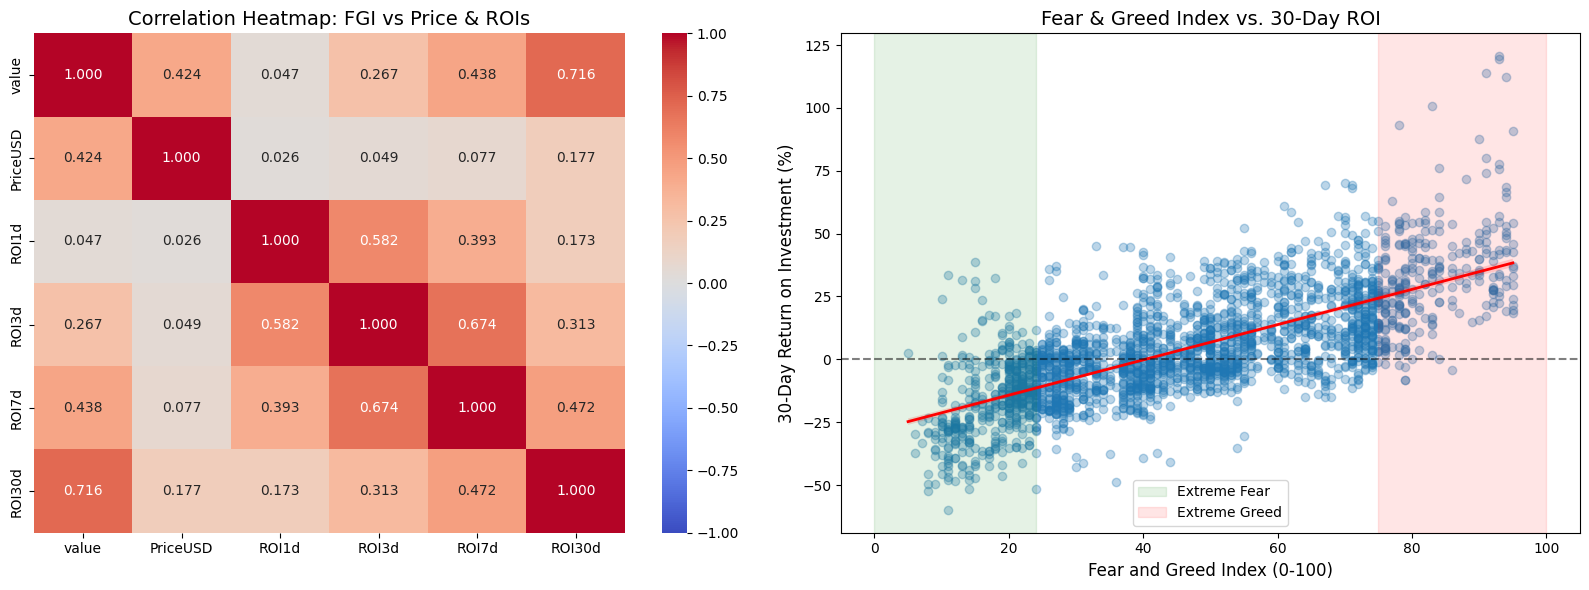

In [9]:
if 'df_analysis' in locals():
    # 1. Compute the Correlation Matrix
    corr_cols = ["value", "PriceUSD", "ROI1d", "ROI3d", "ROI7d", "ROI30d"]
    corr_matrix = df_analysis[corr_cols].corr()
    
    print("--- Pearson Correlation with Fear and Greed Index (FGI) ---")
    fgi_correlations = corr_matrix['value'].drop('value').sort_values(ascending=False)
    print(fgi_correlations.to_string())
    print("-" * 60)
    
    # 2. Plotting the Analysis
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot A: Correlation Heatmap
    sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".3f", ax=axes[0])
    axes[0].set_title("Correlation Heatmap: FGI vs Price & ROIs", fontsize=14)
    
    # Plot B: Scatter Plot of FGI vs ROI30d (Regression Plot)
    # We use ROI30d or ROI7d here as they typically show strong behavioral trends
    sns.regplot(
        data=df_analysis, 
        x="value", 
        y="ROI30d", 
        scatter_kws={'alpha': 0.3, 'color': 'tab:blue'}, 
        line_kws={'color': 'red', 'linewidth': 2},
        ax=axes[1]
    )
    
    # Add a horizontal line at 0% ROI for visual clarity
    axes[1].axhline(0, color='black', linestyle='--', alpha=0.5)
    
    # Add vertical bands for Extreme Fear and Extreme Greed
    axes[1].axvspan(0, 24, color='green', alpha=0.1, label='Extreme Fear')
    axes[1].axvspan(75, 100, color='red', alpha=0.1, label='Extreme Greed')
    
    axes[1].set_title("Fear & Greed Index vs. 30-Day ROI", fontsize=14)
    axes[1].set_xlabel("Fear and Greed Index (0-100)", fontsize=12)
    axes[1].set_ylabel("30-Day Return on Investment (%)", fontsize=12)
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

### FGI has a good correlation to ROI30d values because it captures investor sentiment. People feel 'greedier' when they are having good returns and 'more fearful' when not.
50% of the index's core mathematical weight is directly benchmarked against 30-day historical data, it is practically hardwired to correlate most strongly with the ROI30d metric.
* Volatility (25% weight): It compares Bitcoin's current volatility to its average volatility over the last 30 days and 90 days.
* Market Momentum/Volume (25% weight): It compares current trading volume and momentum against the 30-day and 90-day averages.

#### Moving forward, we’re more interested in using FGI as a forward‑looking tool. 
By mapping sentiment against future ROI, this parameter can guide a disciplined accumulation strategy, like supposedly buying more aggressively during fear phases and scaling back during greed, and helping smooth entry points and improve long‑term returns.

In [10]:
# 1. Ensure btc_df is sorted by time to safely calculate shifts
btc_df = btc_df.sort("time")

# 2. Compute FORWARD-looking 1-day, 3-day, 7-day, and 30-day ROI
# shift(-N) brings the price N days in the future to the current row
btc_df = btc_df.with_columns([
    ((pl.col("PriceUSD").shift(-1) / pl.col("PriceUSD") - 1) * 100).alias("Fwd_ROI1d"),
    ((pl.col("PriceUSD").shift(-3) / pl.col("PriceUSD") - 1) * 100).alias("Fwd_ROI3d"),
    ((pl.col("PriceUSD").shift(-7) / pl.col("PriceUSD") - 1) * 100).alias("Fwd_ROI7d"),
    ((pl.col("PriceUSD").shift(-30) / pl.col("PriceUSD") - 1) * 100).alias("Fwd_ROI30d")
])

print(" Computed Forward ROIs (1d, 3d, 7d, 30d).")

# 3. Extract Date for merging
if "date" not in btc_df.columns:
    btc_date_df = btc_df.with_columns(pl.col("time").dt.date().alias("date"))
else:
    btc_date_df = btc_df

# 4. Merge with the fgi_df we created earlier
if 'fgi_df' in locals():
    # Convert Pandas fgi_df to Polars for the join
    fgi_pl = pl.from_pandas(fgi_df)
    
    # Inner join on date
    merged_fwd_df = btc_date_df.join(fgi_pl, on="date", how="inner")
    
    # Select our target columns and convert to Pandas for easy plotting/correlation
    target_cols = ["date", "PriceUSD", "Fwd_ROI1d", "Fwd_ROI3d", "Fwd_ROI7d", "Fwd_ROI30d", "value"]
    df_analysis = merged_fwd_df.select(target_cols).to_pandas()
    
    # Drop NaNs (which will occur at the very END of the dataset due to forward shifts)
    df_analysis = df_analysis.dropna()
    
    print(f" Successfully merged FGI with Forward ROIs. Analyzable records: {len(df_analysis)}")
    display(df_analysis.head(20))
else:
    print(" 'fgi_df' not found. Please make sure the previous FGI fetching cell was executed.")

 Computed Forward ROIs (1d, 3d, 7d, 30d).
 Successfully merged FGI with Forward ROIs. Analyzable records: 2522


,date,PriceUSD,Fwd_ROI1d,Fwd_ROI3d,Fwd_ROI7d,Fwd_ROI30d,value
0,2018-02-01,9039.865075,-2.807428,-8.731747,-9.085138,26.392158,30.0
1,2018-02-02,8786.077380,3.938310,-22.040949,-1.429807,30.463035,15.0
2,2018-02-03,9132.100322,-9.653567,-15.258881,-6.590023,26.374677,40.0
3,2018-02-04,8250.526896,-16.980544,-7.586564,-1.864104,29.410344,24.0
4,2018-02-05,6849.542559,12.980449,19.987295,30.047665,44.580240,11.0
5,2018-02-06,7738.643960,-1.473754,11.911770,10.148070,20.569902,8.0
6,2018-02-07,7624.595390,7.790387,11.878629,24.167914,21.686971,36.0
7,2018-02-08,8218.580852,5.376508,-1.482645,22.974188,6.910920,30.0
8,2018-02-09,8660.453468,-1.502931,2.854547,17.653383,9.850315,44.0
9,2018-02-10,8530.292805,-5.082643,-0.074158,29.955661,7.240049,54.0


--- Pearson Correlation: Current FGI vs FORWARD Returns ---
PriceUSD      0.423708
Fwd_ROI30d    0.146626
Fwd_ROI7d     0.077552
Fwd_ROI3d     0.062701
Fwd_ROI1d     0.037707
------------------------------------------------------------


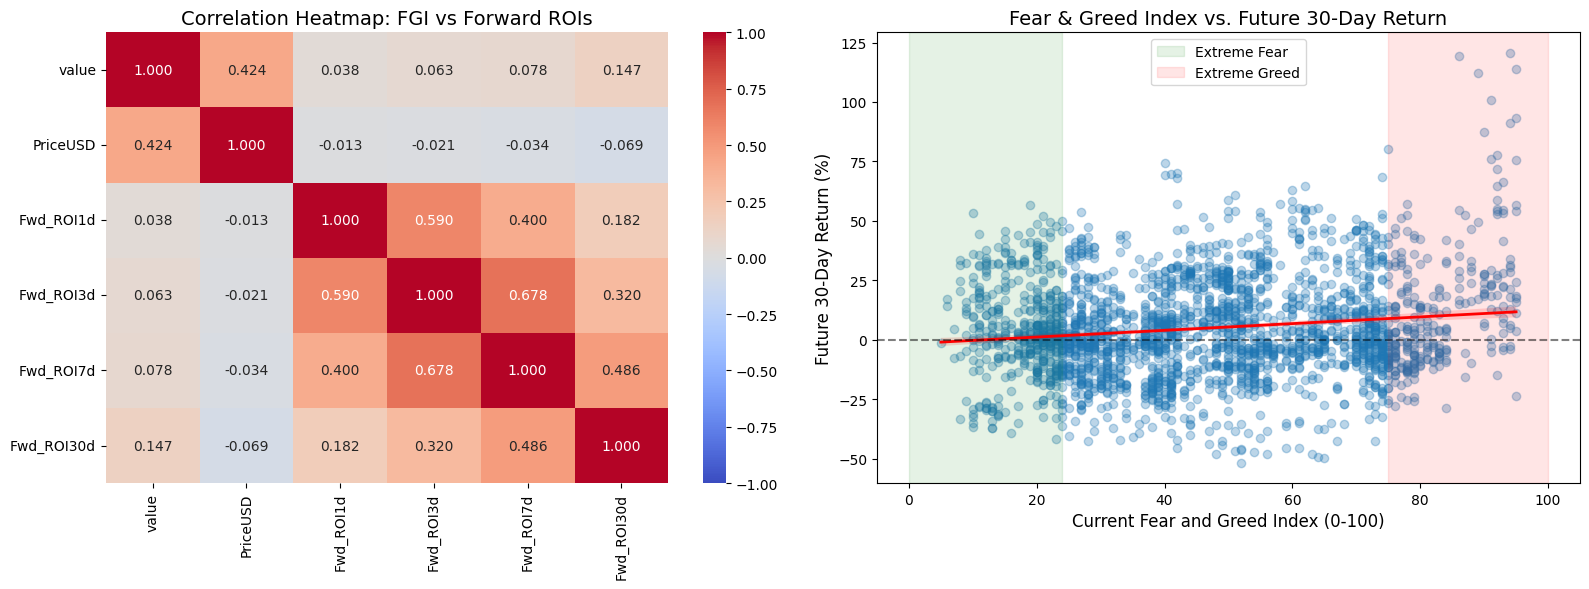

In [11]:
if 'df_analysis' in locals():
    # 1. Compute the Correlation Matrix
    corr_cols = ["value", "PriceUSD", "Fwd_ROI1d", "Fwd_ROI3d", "Fwd_ROI7d", "Fwd_ROI30d"]
    corr_matrix = df_analysis[corr_cols].corr()
    
    print("--- Pearson Correlation: Current FGI vs FORWARD Returns ---")
    fgi_correlations = corr_matrix['value'].drop('value').sort_values(ascending=False)
    print(fgi_correlations.to_string())
    print("-" * 60)
    
    # 2. Plotting the Analysis
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot A: Correlation Heatmap
    sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".3f", ax=axes[0])
    axes[0].set_title("Correlation Heatmap: FGI vs Forward ROIs", fontsize=14)
    
    # Plot B: Scatter Plot of FGI vs Fwd_ROI30d
    sns.regplot(
        data=df_analysis, 
        x="value", 
        y="Fwd_ROI30d", 
        scatter_kws={'alpha': 0.3, 'color': 'tab:blue'}, 
        line_kws={'color': 'red', 'linewidth': 2},
        ax=axes[1]
    )
    
    # Add a horizontal line at 0% ROI for visual clarity
    axes[1].axhline(0, color='black', linestyle='--', alpha=0.5)
    
    # Add vertical bands for Extreme Fear and Extreme Greed
    axes[1].axvspan(0, 24, color='green', alpha=0.1, label='Extreme Fear')
    axes[1].axvspan(75, 100, color='red', alpha=0.1, label='Extreme Greed')
    
    axes[1].set_title("Fear & Greed Index vs. Future 30-Day Return", fontsize=14)
    axes[1].set_xlabel("Current Fear and Greed Index (0-100)", fontsize=12)
    axes[1].set_ylabel("Future 30-Day Return (%)", fontsize=12)
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

## FORWARD ROI of 1 to 7 days seem to be not useful since the correlation is too low. Also, it might be better to separate the FGI to bins from extreme fear to extreme greed

### Interpreting Short-Term vs. Medium-Term Forward Returns

The correlation heatmap reveals a crucial dynamic about market sentiment and Bitcoin price action: **Short-term price velocity is mostly noise, but medium-term momentum is highly persistent.**

* **The Noise of the Micro-Trend (1d, 3d, 7d):** Forward returns under 7 days show almost zero correlation with the Fear and Greed Index. Sentiment is a macroeconomic indicator; it does not reliably predict day-to-day random walks or immediate price bounces.
* **The Momentum Engine (30d):** The 30-day forward return exhibits a positive relationship with sentiment. When the market enters "Greed," the trend tends to persist over the next month. Extreme euphoria rarely collapses instantly; it sustains itself, meaning a naive contrarian strategy (shorting the moment the market turns greedy) would result in missing significant upside momentum.

To build a robust accumulation model, we must expand our time horizon beyond 30 days. We need to identify the macroeconomic phase shifts—the points where accumulating capital is statistically safest, and the points where we should begin distributing (selling) our accumulated Bitcoin.

--- Average 30-Day Forward Return by FGI Bracket ---
                             mean    median  count
FGI_Bracket                                       
Extreme Fear (0-24)      3.767502  1.773568    497
Fear (25-45)             1.111344 -0.444955    758
Neutral (46-55)          5.829062  6.068682    387
Greed (56-75)            6.083721  1.587965    609
Extreme Greed (76-100)  13.773986  6.966540    271
------------------------------------------------------------


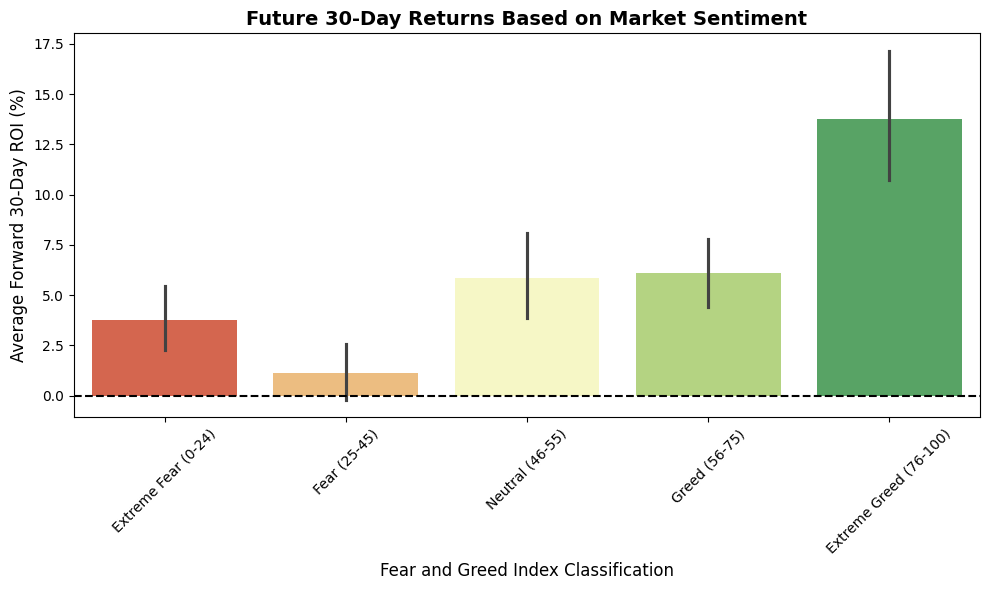

In [12]:
if 'df_analysis' in locals():
    # 1. Create bins for the Fear and Greed Index
    # Typical CMC/Alternative.me classifications:
    bins = [0, 24, 45, 55, 75, 100]
    labels = ['Extreme Fear (0-24)', 'Fear (25-45)', 'Neutral (46-55)', 'Greed (56-75)', 'Extreme Greed (76-100)']
    
    df_analysis['FGI_Bracket'] = pd.cut(df_analysis['value'], bins=bins, labels=labels, include_lowest=True)
    
    # 2. Calculate the average forward 30-day return for each bracket
    fgi_grouped = df_analysis.groupby('FGI_Bracket', observed=False)['Fwd_ROI30d'].agg(['mean', 'median', 'count'])
    
    print("--- Average 30-Day Forward Return by FGI Bracket ---")
    print(fgi_grouped)
    print("-" * 60)
    
    # 3. Visualize the non-linear relationship
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # We use a barplot to show the mean return with error bars for variance
    sns.barplot(data=df_analysis, x='FGI_Bracket', y='Fwd_ROI30d', hue='FGI_Bracket', ax=ax, palette='RdYlGn')
    
    ax.set_title("Future 30-Day Returns Based on Market Sentiment", fontsize=14, fontweight='bold')
    ax.set_xlabel("Fear and Greed Index Classification", fontsize=12)
    ax.set_ylabel("Average Forward 30-Day ROI (%)", fontsize=12)
    ax.axhline(0, color='black', linestyle='--')
    
    # Rotate x-axis labels if they overlap
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Over a 30 day timeframe, **Extreme Greed** has the highest returns (13.77% on average). In this periods, the *hype* is definitely real, and selling after 30 days would be the most profitable approach.

But on longer timeframes, I think betting on extreme greed periods would not be sustainable since the hype will die down eventually. With that, 90- and 180-day timeframes should also be checked.

In [13]:
# Ensure btc_df is sorted by time to safely calculate shifts
btc_df = btc_df.sort("time")

# Compute all three time horizons in one go
btc_df = btc_df.with_columns([
    ((pl.col("PriceUSD").shift(-30) / pl.col("PriceUSD") - 1) * 100).alias("Fwd_ROI30d"),
    ((pl.col("PriceUSD").shift(-90) / pl.col("PriceUSD") - 1) * 100).alias("Fwd_ROI90d"),
    ((pl.col("PriceUSD").shift(-180) / pl.col("PriceUSD") - 1) * 100).alias("Fwd_ROI180d")
])

# Extract Date and Merge (Assuming fgi_df is already loaded)
btc_date_df = btc_df.with_columns(pl.col("time").dt.date().alias("date")) if "date" not in btc_df.columns else btc_df
fgi_pl = pl.from_pandas(fgi_df)
merged_long_fwd = btc_date_df.join(fgi_pl, on="date", how="inner")

# Select all target columns for the combined analysis
target_cols = ["date", "PriceUSD", "Fwd_ROI30d", "Fwd_ROI90d", "Fwd_ROI180d", "value"]
df_long_analysis = merged_long_fwd.select(target_cols).to_pandas().dropna()

print(f" Successfully merged FGI with 30d, 90d, and 180d Forward ROIs. Analyzable records: {len(df_long_analysis)}")

 Successfully merged FGI with 30d, 90d, and 180d Forward ROIs. Analyzable records: 2522


--- Average 30-Day Forward Return ---
                             mean    median
FGI_Bracket                                
Extreme Fear (0-24)      3.767502  1.773568
Fear (25-45)             1.111344 -0.444955
Neutral (46-55)          5.829062  6.068682
Greed (56-75)            6.083721  1.587965
Extreme Greed (76-100)  13.773986  6.966540

--- Average 90-Day Forward Return ---
                             mean     median
FGI_Bracket                                 
Extreme Fear (0-24)      3.056156  -2.939646
Fear (25-45)            12.094956   4.564025
Neutral (46-55)         24.457136  12.774654
Greed (56-75)           20.550190   8.730226
Extreme Greed (76-100)  41.747939  13.382030

--- Average 180-Day Forward Return ---
                             mean     median  count
FGI_Bracket                                        
Extreme Fear (0-24)     16.704321  -2.665854    497
Fear (25-45)            44.907282  18.778558    758
Neutral (46-55)         60.180285  36.142722    387


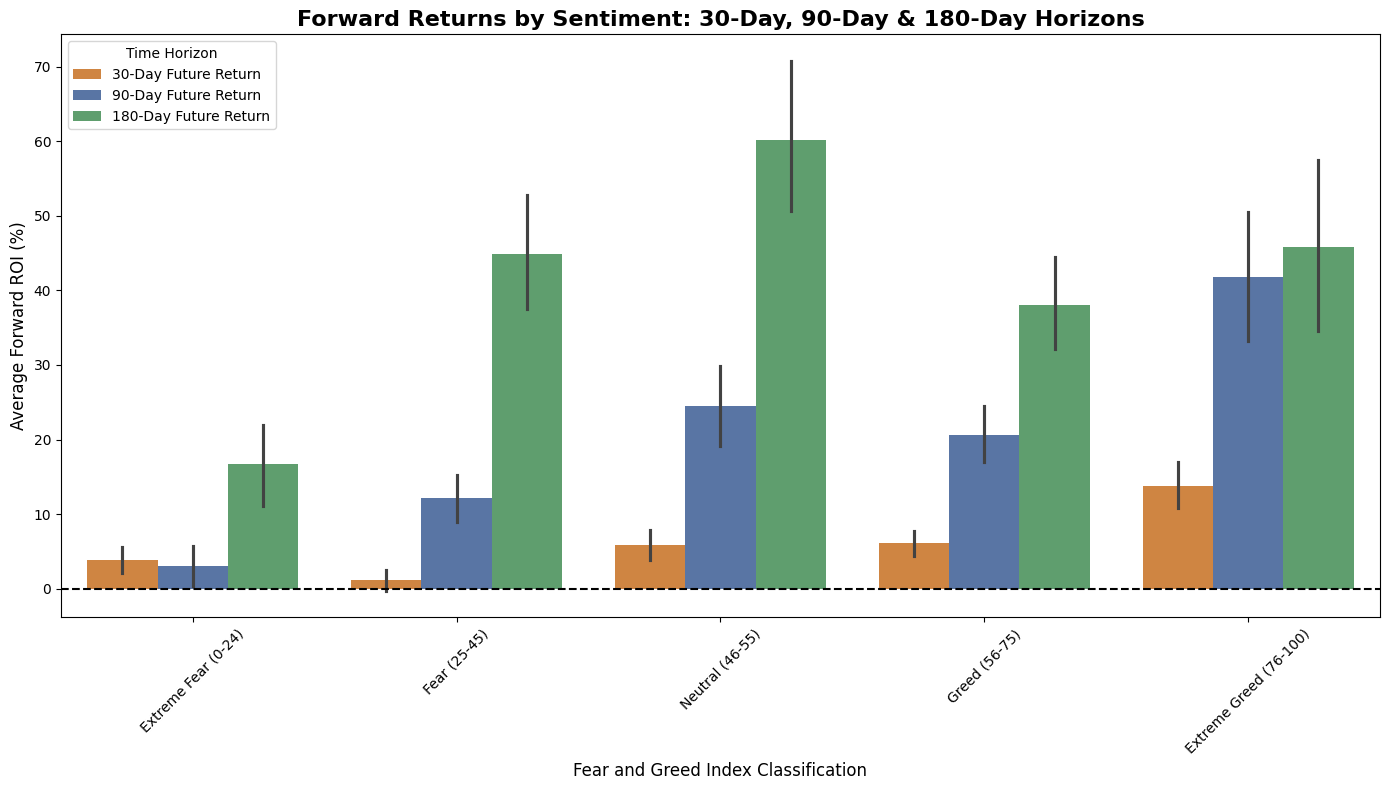

In [14]:
if 'df_long_analysis' in locals():
    # 1. Create bins for the Fear and Greed Index
    bins = [0, 24, 45, 55, 75, 100]
    labels = ['Extreme Fear (0-24)', 'Fear (25-45)', 'Neutral (46-55)', 'Greed (56-75)', 'Extreme Greed (76-100)']
    
    df_long_analysis['FGI_Bracket'] = pd.cut(df_long_analysis['value'], bins=bins, labels=labels, include_lowest=True)
    
    # 2. Calculate the average forward returns for all three horizons
    fgi_grouped_30 = df_long_analysis.groupby('FGI_Bracket', observed=False)['Fwd_ROI30d'].agg(['mean', 'median'])
    fgi_grouped_90 = df_long_analysis.groupby('FGI_Bracket', observed=False)['Fwd_ROI90d'].agg(['mean', 'median'])
    fgi_grouped_180 = df_long_analysis.groupby('FGI_Bracket', observed=False)['Fwd_ROI180d'].agg(['mean', 'median', 'count'])
    
    print("--- Average 30-Day Forward Return ---")
    print(fgi_grouped_30)
    print("\n--- Average 90-Day Forward Return ---")
    print(fgi_grouped_90)
    print("\n--- Average 180-Day Forward Return ---")
    print(fgi_grouped_180)
    print("-" * 60)
    
    # 3. Restructure the dataframe to include all three ROI horizons
    df_melted = df_long_analysis.melt(
        id_vars=['FGI_Bracket'], 
        value_vars=['Fwd_ROI30d', 'Fwd_ROI90d', 'Fwd_ROI180d'],
        var_name='ROI_Horizon', 
        value_name='Forward_Return'
    )
    
    # 4. Visualize the non-linear relationship over expanding time horizons
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Use a grouped barplot with three colors
    sns.barplot(
        data=df_melted, 
        x='FGI_Bracket', 
        y='Forward_Return', 
        hue='ROI_Horizon', 
        palette=['#E6842A', '#4C72B0', '#55A868'], # Orange (30d), Blue (90d), Green (180d)
        ax=ax
    )
    
    ax.set_title("Forward Returns by Sentiment: 30-Day, 90-Day & 180-Day Horizons", fontsize=16, fontweight='bold')
    ax.set_xlabel("Fear and Greed Index Classification", fontsize=12)
    ax.set_ylabel("Average Forward ROI (%)", fontsize=12)
    ax.axhline(0, color='black', linestyle='--', linewidth=1.5)
    
    # Prettify the legend to match the three horizons
    handles, _ = ax.get_legend_handles_labels()
    ax.legend(handles, ['30-Day Future Return', '90-Day Future Return', '180-Day Future Return'], title="Time Horizon", loc='upper left')
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Strategic Interpretation: Momentum, Mean Reversion, and Market Regimes

The forward-return data across 30, 90, and 180-day horizons challenges traditional contrarian adages (e.g., "buy when there is blood in the streets") and reveals the heavy influence of momentum in Bitcoin market cycles. 


#### What the Data Actually Means:
1. **The Momentum Engine (Extreme Greed):** Over short timeframes (30 days), **Extreme Greed** is highly profitable, boasting a 13.77% average return. Euphoria in crypto markets sustains itself; cycle tops take time to form, and betting against a greedy market prematurely means missing significant upside. However, notice the 180-day median return drops to 8.47%, indicating that over a 6-month horizon, these greedy tops eventually collapse.
2. **The Crypto Winter Trap (Extreme Fear):** Buying maximum fear is statistically dangerous over long horizons. While there is a slight 30-day capitulation bounce (1.77% median), the 90-day and 180-day median returns plunge negative (-2.93% and -2.66%). This proves that "Extreme Fear" does not mark V-shaped recoveries; it marks the beginning of prolonged, grueling bear markets. 
3. **The "Disbelief" Sweet Spot (Neutral):** The most striking finding is the dominance of the **Neutral (46-55)** bracket over long timeframes. Buying when the market is quiet, boring, and emotionally flat yields a staggering 60.18% average and 36.14% median 180-day return. This represents the optimal macroeconomic launchpad—the phase where bear markets have exhausted themselves, but retail FOMO has not yet ignited.

---


This reveals a critical dynamic for our (possibly a) 4-year accumulation and distribution strategy: the utility of market sentiment changes depending on **how much time is left until our scheduled sell date** (e.g., the end of a half-year liquidation target). 


By analyzing short-term momentum versus long-term mean reversion, we can dynamically adjust our accumulation weighting based on our time-to-target:

#### 1. Early in the Period (Far from Sell Target: >90 to 180 Days)
When we are at the beginning of an accumulation period, our time horizon is long, and we must optimize for the 180-day forward returns. 
* **The "Disbelief" Sweet Spot (Neutral 46-55):** This is the optimal macroeconomic launchpad. Buying when the market is emotionally flat yields a staggering 60.18% average and 36.14% median 180-day return. The model should heavily weight accumulation here.
* **Avoid Extreme Greed:** Buying euphoria early in the period is statistically inefficient. While it feels good in the moment, the 180-day median return drops to 8.47%, meaning the cyclical top will likely collapse before our sell date arrives.
* **The "Crypto Winter" Trap (Extreme Fear 0-24):** Buying maximum fear early in a cycle catches a falling knife, evidenced by a negative 180-day median return (-2.66%). The model should stick to a conservative, baseline Dollar Cost Average (DCA) rather than deploying lump-sum capital.

#### 2. Late in the Period (Close to Sell Target: <30 Days)
As we approach the end of the period, our time horizon shrinks, and long-term mean reversion no longer matters. We shift strictly to a momentum-based logic.
* **The Momentum Engine (Extreme Greed 76-100):** If the market hits Extreme Greed close to our liquidation date, it becomes **highly useful to increase buying**. The 30-day forward return is a massive 13.77%. Euphoria in crypto markets sustains itself in the short term, allowing the model to aggressively ride the momentum straight into the target sell date before the inevitable crash occurs.

In the possible future, the accumulation algorithm should use a time-decaying weight system. Extreme Greed triggers profit-taking/reduced buying when the time horizon is long, but it triggers aggressive momentum buying when the time horizon is short enough to safely cash out.